# Data Insegtion

In [1]:
#library import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [2]:
#import/read data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#rename columns
df.rename(
    columns={
        "customerID" : "CustomerID",
        "gender" : "Gender",
        "tenure" : "Tenure"
    }, inplace=True
)

df.head(3)

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


The dataset was obtained from the following source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn. The column names were standardized by changing `customerID` to `CustomerID`, `gender` to `Gender`, and `tenure` to `Tenure`.

# Exploratory Data Analysis

In [4]:
#identify columns and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#quantitative analysis/descriptive stastitics
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
#categorical analysis
cols = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for i in cols:
    print(df[i].value_counts())
    print()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
No                     3473
Yes                    2044
No internet service    15

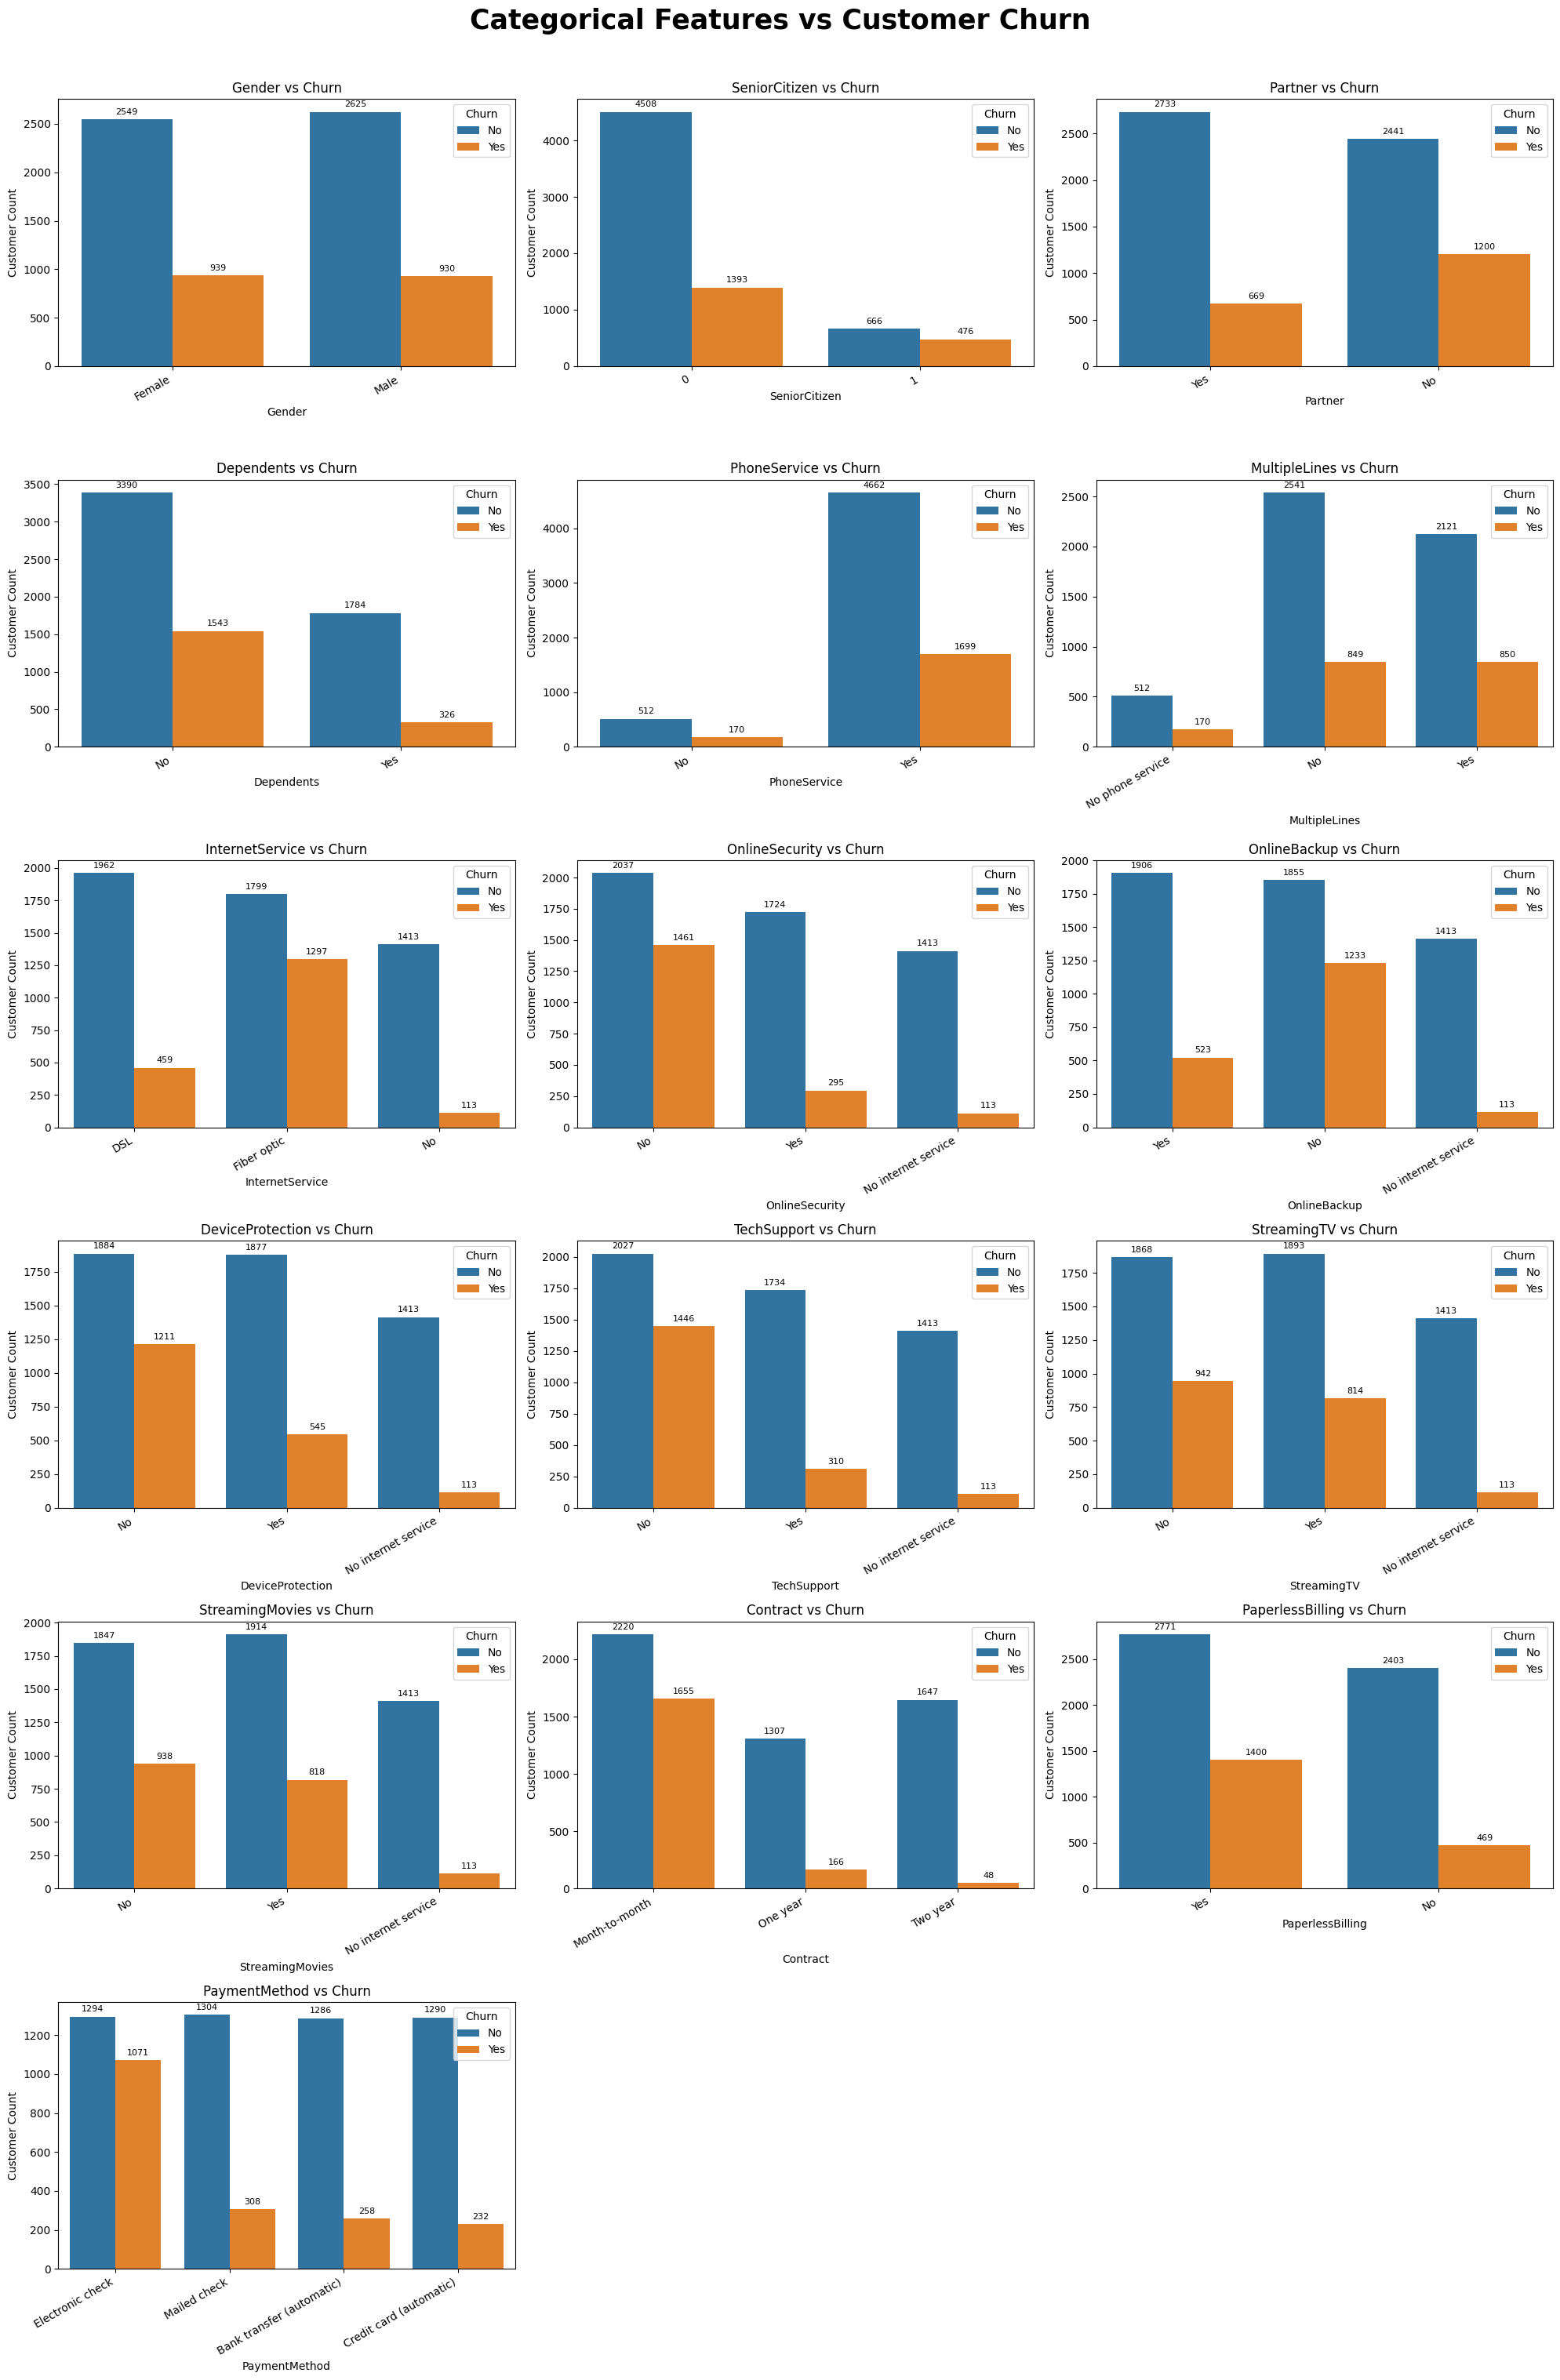

In [7]:
#categorical features vs label
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 30))
axes = axes.flatten()

for i, column in enumerate(cols):
    ax = sns.countplot(
        data=df,
        x=column,
        hue='Churn',
        ax=axes[i]
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=30)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(
    'Categorical Features vs Customer Churn',
    fontsize=25,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

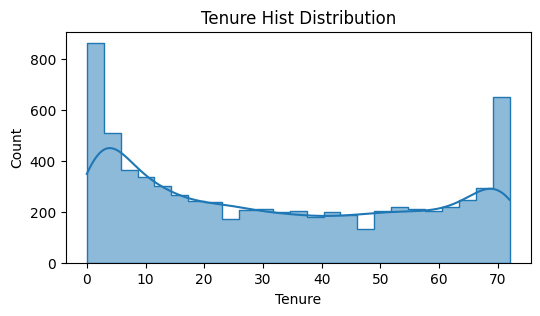

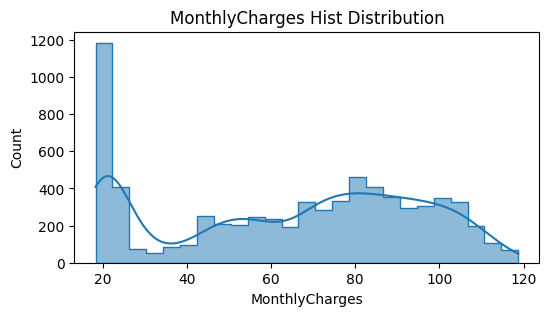

In [8]:
#numerical features distribution (histogram plot)
for i in df.select_dtypes(include=['number']).drop(columns='SeniorCitizen'):
    plt.figure(figsize=(6,3))
    plt.title(f"{i} Hist Distribution")
    sns.histplot(data=df, x=i, bins=25, kde=1, element='step')
    
    plt.show()

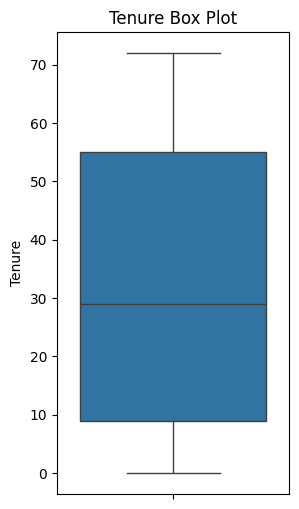

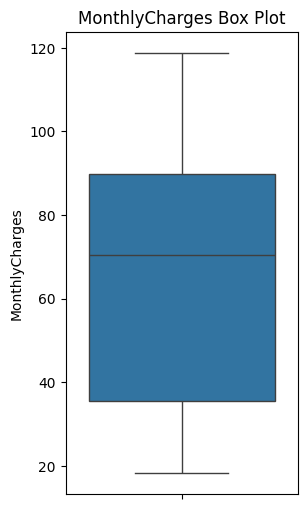

Tenure: 0 outlier
MonthlyCharges: 0 outlier


In [9]:
#outlier detection (boxplot)
for i in df.select_dtypes(include=['number']).drop(columns='SeniorCitizen'):
    plt.figure(figsize=(3,6))
    plt.title(f"{i} Box Plot")
    sns.boxplot(data=df, y=i)
    
    plt.show()

for i in df.select_dtypes(include=['number']).drop(columns='SeniorCitizen'):
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df[
        (df[i] < lower_bound) | (df[i] > upper_bound)
    ].shape[0]

    print(f'{i}: {outlier_count} outlier')

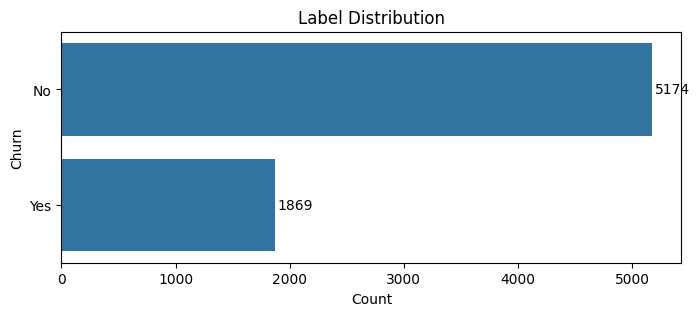

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Label Gap: 46.93%
Dataset: imbalance


In [10]:
#label distribution & imbalance detection
plt.figure(figsize=(8,3))
plt.title("Label Distribution")
ax = sns.countplot(data=df['Churn'])

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.xlabel("Count")

plt.show()

print("="*75)
label_percent = df['Churn'].value_counts(normalize=True) * 100

selisih = label_percent.max() - label_percent.min()

print(label_percent)
print(f'\nLabel Gap: {selisih:.2f}%')

if selisih >= 10:
    print('Dataset: imbalance')
else:
    print('Dataset: balance')

Initial Dataset Analysis

- The initial dataset contains **7,043 rows and 21 columns**, with `Churn` as the binary target variable (`Yes`/`No`). `TotalCharges` is incorrectly detected as an object data type and requires conversion to numeric.

- `Tenure` shows a relatively stable distribution, while `MonthlyCharges` exhibits right skewness. However, no significant outliers were identified from the box plot, so no further treatment is required.

- Several categorical variables contain inconsistent representations, such as binary values appearing as both `Yes/No` and `0/1`, as well as ambiguous categories such as `No` and `No Internet Service`. These require standardization during preprocessing.

- The target variable `Churn` shows a substantial class imbalance, with the `No` class accounting for approximately **73%** of observations and a **47-percentage-point gap** between the two classes. Therefore, class imbalance will be addressed in the subsequent modeling stage.

# Data Preprocessing

## Null and Duplicated Handling

In [11]:
#missing value checker
print(df.isna().sum())

CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
#duplicates checker
print(df.drop(columns="CustomerID").duplicated().sum())

22


In [13]:
#drip duplicates
df.drop_duplicates(subset=df.drop(columns="CustomerID"),inplace=True)
print(df.drop(columns="CustomerID").duplicated().sum())

0


No missing values were found. After checking for duplicates while excluding `CustomerID`, **22 duplicate records** were identified and removed.

## Transformation

In [14]:
print(df.info())
df.head(2)

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7021 non-null   object 
 1   Gender            7021 non-null   object 
 2   SeniorCitizen     7021 non-null   int64  
 3   Partner           7021 non-null   object 
 4   Dependents        7021 non-null   object 
 5   Tenure            7021 non-null   int64  
 6   PhoneService      7021 non-null   object 
 7   MultipleLines     7021 non-null   object 
 8   InternetService   7021 non-null   object 
 9   OnlineSecurity    7021 non-null   object 
 10  OnlineBackup      7021 non-null   object 
 11  DeviceProtection  7021 non-null   object 
 12  TechSupport       7021 non-null   object 
 13  StreamingTV       7021 non-null   object 
 14  StreamingMovies   7021 non-null   object 
 15  Contract          7021 non-null   object 
 16  PaperlessBilling  7021 non-null   object 
 17  

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [15]:
#data type conversion and categorical value standardization

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.dropna(subset="TotalCharges", inplace=True)

cols1 = [
    'Partner', 'Dependents', 'PaperlessBilling', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'StreamingTV',
    'OnlineBackup'
        ]

for col in cols1:
    df[col] = df[col].map({
        'Yes': True,
        'No': False,
        'No phone service' : False,
        'No internet service' : False,
    })

df = df.astype({
    "SeniorCitizen" : "bool"
})

print(df.info())
df.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7010 non-null   object 
 1   Gender            7010 non-null   object 
 2   SeniorCitizen     7010 non-null   bool   
 3   Partner           7010 non-null   bool   
 4   Dependents        7010 non-null   bool   
 5   Tenure            7010 non-null   int64  
 6   PhoneService      7010 non-null   bool   
 7   MultipleLines     7010 non-null   bool   
 8   InternetService   7010 non-null   object 
 9   OnlineSecurity    7010 non-null   bool   
 10  OnlineBackup      7010 non-null   bool   
 11  DeviceProtection  7010 non-null   bool   
 12  TechSupport       7010 non-null   bool   
 13  StreamingTV       7010 non-null   bool   
 14  StreamingMovies   7010 non-null   bool   
 15  Contract          7010 non-null   object 
 16  PaperlessBilling  7010 non-null   bool   
 17  

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,False,DSL,False,True,False,False,False,False,Month-to-month,True,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,False,True,False,False,False,One year,False,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,True,False,False,False,False,Month-to-month,True,Mailed check,53.85,108.15,Yes


In [16]:
#remove irrelevant column
df.drop(columns="CustomerID", inplace=True)
df.head(3)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,False,True,False,1,False,False,DSL,False,True,False,False,False,False,Month-to-month,True,Electronic check,29.85,29.85,No
1,Male,False,False,False,34,True,False,DSL,True,False,True,False,False,False,One year,False,Mailed check,56.95,1889.50,No
2,Male,False,False,False,2,True,False,DSL,True,True,False,False,False,False,Month-to-month,True,Mailed check,53.85,108.15,Yes


In [17]:
#categorical feature encoding
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

for i in df.select_dtypes(include=['object']).drop(columns='Churn'):
    df[[i]] = encoder.fit_transform(df[[i]])
    df[i] = df[i].astype(int)
    print(f"{i} Encoder Mapping:")
    print(encoder.categories_)
    print()


Gender Encoder Mapping:
[array(['Female', 'Male'], dtype=object)]

InternetService Encoder Mapping:
[array(['DSL', 'Fiber optic', 'No'], dtype=object)]

Contract Encoder Mapping:
[array(['Month-to-month', 'One year', 'Two year'], dtype=object)]

PaymentMethod Encoder Mapping:
[array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object)]



- Binary feature values were standardized into `True/False` where categories represented the same meaning.

- `TotalCharges` was converted to a numeric data type; however, using `errors='coerce'` resulted in 10 records being removed because some entries contained whitespace-only values (e.g., `"    "`) that were not recognized as null in the previous step.

- `CustomerID` was removed because it does not provide meaningful information for model training.

- Due to the relatively large number of categorical features, Ordinal Encoding was applied to avoid generating a high-dimensional sparse dataset.

## Recheck

In [18]:
df.head(3)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,False,True,False,1,False,False,0,False,True,False,False,False,False,0,True,2,29.85,29.85,No
1,1,False,False,False,34,True,False,0,True,False,True,False,False,False,1,False,3,56.95,1889.50,No
2,1,False,False,False,2,True,False,0,True,True,False,False,False,False,0,True,3,53.85,108.15,Yes


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7010 non-null   int32  
 1   SeniorCitizen     7010 non-null   bool   
 2   Partner           7010 non-null   bool   
 3   Dependents        7010 non-null   bool   
 4   Tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   bool   
 6   MultipleLines     7010 non-null   bool   
 7   InternetService   7010 non-null   int32  
 8   OnlineSecurity    7010 non-null   bool   
 9   OnlineBackup      7010 non-null   bool   
 10  DeviceProtection  7010 non-null   bool   
 11  TechSupport       7010 non-null   bool   
 12  StreamingTV       7010 non-null   bool   
 13  StreamingMovies   7010 non-null   bool   
 14  Contract          7010 non-null   int32  
 15  PaperlessBilling  7010 non-null   bool   
 16  PaymentMethod     7010 non-null   int32  
 17  

<Axes: >

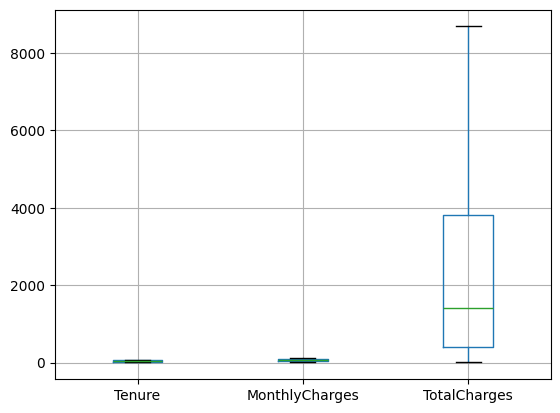

In [20]:
cols1 = ['Tenure', 'MonthlyCharges', 'TotalCharges']

df[cols1].boxplot()
    

A final recheck was conducted to ensure the preprocessing results were consistent and no further issues were identified. The dataset is ready for the next stage.

# Modelling & Evaluation

In [21]:
df_final = df.copy()

In [22]:
X = df_final.drop(columns='Churn')
y = df['Churn']

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.combine import SMOTETomek

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True, random_state=42, test_size=0.2)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (5608, 19)
Testing Shape: (1402, 19)


In [24]:
smote_tomek = SMOTETomek(random_state=42)

X_train_smote, y_train_smote = smote_tomek.fit_resample(
    X_train,
    y_train
)

In [25]:
print("Before SMOTE-Tomek:")
print(y_train.value_counts())

print("\nAfter SMOTE-Tomek:")
print(y_train_smote.value_counts())

Before SMOTE-Tomek:
Churn
No     4122
Yes    1486
Name: count, dtype: int64

After SMOTE-Tomek:
Churn
No     3767
Yes    3767
Name: count, dtype: int64


## Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(
    max_iter=100000,
    random_state=42
)

In [27]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_normal = GridSearchCV(
    estimator=logistic,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

grid_smote = GridSearchCV(
    estimator=logistic,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

In [28]:
grid_normal.fit(X_train, y_train)

grid_smote.fit(X_train_smote, y_train_smote)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,penalty,'l2'


In [29]:
print("Normal")
print("Best Parameter:", grid_normal.best_params_)
print(f"Best CV Score: {grid_normal.best_score_:.4f}")

print()

print("SMOTE-Tomek")
print("Best Parameter:", grid_smote.best_params_)
print(f"Best CV Score: {grid_smote.best_score_:.4f}")

Normal
Best Parameter: {'C': 1, 'class_weight': None, 'solver': 'liblinear'}
Best CV Score: 0.7337

SMOTE-Tomek
Best Parameter: {'C': 0.1, 'class_weight': None, 'solver': 'lbfgs'}
Best CV Score: 0.8106


In [30]:
best_normal = grid_normal.best_estimator_
y_pred_normal = best_normal.predict(X_test)

best_smote = grid_smote.best_estimator_
y_pred_smote = best_smote.predict(X_test)

### Evaluation

In [31]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("Normal")
print(f"Accuracy: {accuracy_score(y_test, y_pred_normal):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_normal, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_normal))

print()

print("SMOTE-Tomek")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_smote, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_smote))

Normal
Accuracy: 0.7974
F1 Score: 0.7227

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1031
         Yes       0.64      0.53      0.58       371

    accuracy                           0.80      1402
   macro avg       0.74      0.71      0.72      1402
weighted avg       0.79      0.80      0.79      1402


SMOTE-Tomek
Accuracy: 0.7511
F1 Score: 0.7105

              precision    recall  f1-score   support

          No       0.88      0.77      0.82      1031
         Yes       0.52      0.71      0.60       371

    accuracy                           0.75      1402
   macro avg       0.70      0.74      0.71      1402
weighted avg       0.79      0.75      0.76      1402



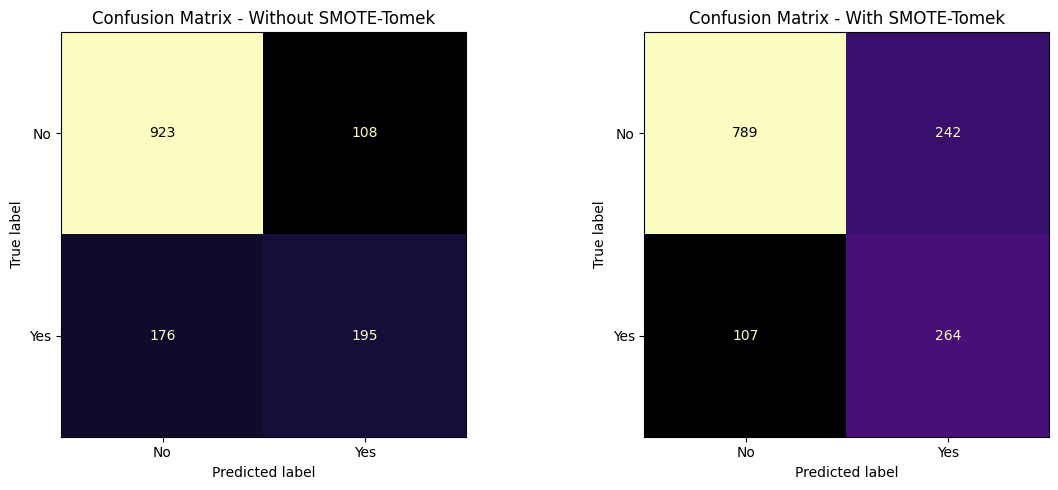

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_normal = confusion_matrix(y_test, y_pred_normal)
cm_smote = confusion_matrix(y_test, y_pred_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_normal,
    display_labels=['No', 'Yes']
).plot(ax=axes[0], cmap='magma', colorbar=False)

axes[0].set_title('Confusion Matrix - Without SMOTE-Tomek')

ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=['No', 'Yes']
).plot(ax=axes[1], cmap='magma', colorbar=False)

axes[1].set_title('Confusion Matrix - With SMOTE-Tomek')

plt.tight_layout()
plt.show()

In [33]:
importance_normal = np.abs(best_normal.coef_[0])
importance_smote = np.abs(best_smote.coef_[0])

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Normal': importance_normal,
    'SMOTE-Tomek': importance_smote
})

feature_importance['Mean'] = (
    feature_importance['Normal'] +
    feature_importance['SMOTE-Tomek']
) / 2

In [34]:
normal_importance = feature_importance.sort_values(
    by='Normal',
    ascending=True
)

smote_importance = feature_importance.sort_values(
    by='SMOTE-Tomek',
    ascending=True
)

top_normal = normal_importance.tail(10)
top_smote = smote_importance.tail(10)

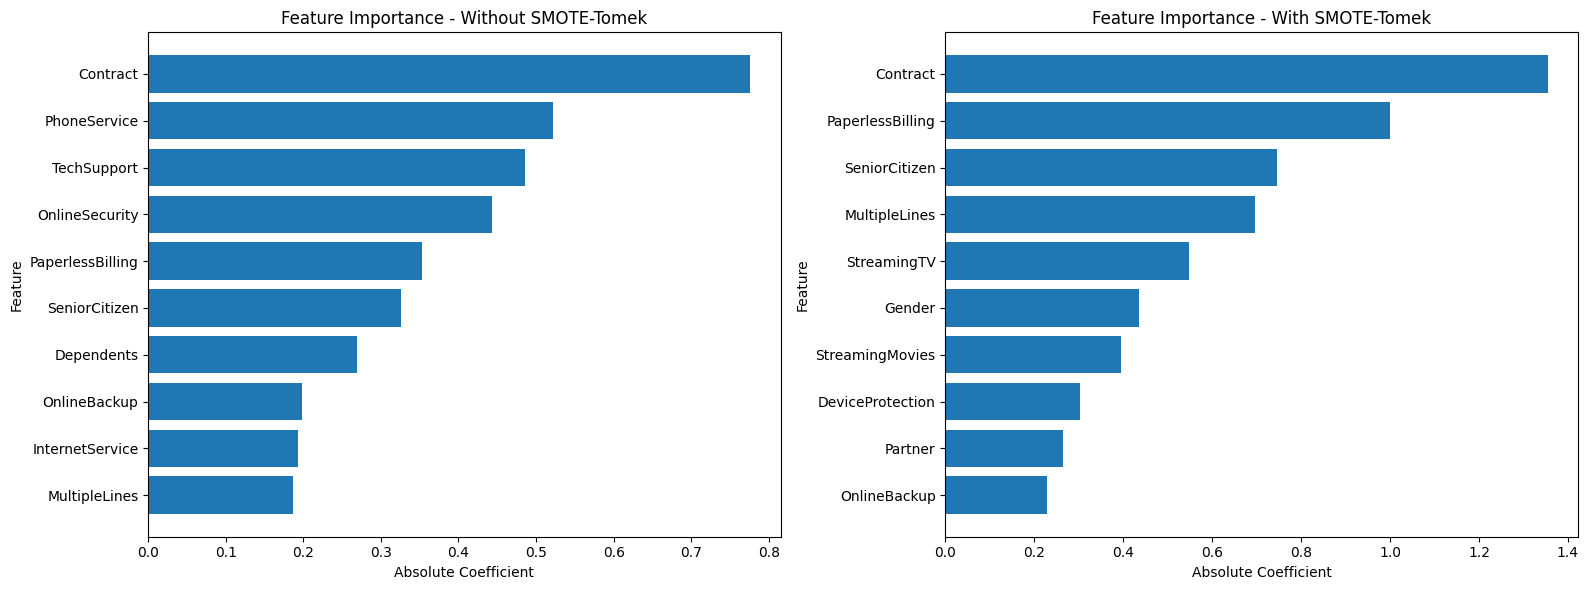

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    top_normal['Feature'],
    top_normal['Normal']
)
axes[0].set_title('Feature Importance - Without SMOTE-Tomek')
axes[0].set_xlabel('Absolute Coefficient')
axes[0].set_ylabel('Feature')

axes[1].barh(
    top_smote['Feature'],
    top_smote['SMOTE-Tomek']
)
axes[1].set_title('Feature Importance - With SMOTE-Tomek')
axes[1].set_xlabel('Absolute Coefficient')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

## Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state=42
)

In [37]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_normal = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

grid_smote = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

In [38]:
grid_normal.fit(X_train, y_train)

grid_smote.fit(X_train_smote, y_train_smote)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,n_estimators,300


In [39]:
print("Normal")
print("Best Parameter:", grid_normal.best_params_)
print(f"Best CV Score: {grid_normal.best_score_:.4f}")

print()

print("SMOTE-Tomek")
print("Best Parameter:", grid_smote.best_params_)
print(f"Best CV Score: {grid_smote.best_score_:.4f}")

Normal
Best Parameter: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.7205

SMOTE-Tomek
Best Parameter: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.8645


In [40]:
best_normal = grid_normal.best_estimator_
y_pred_normal = best_normal.predict(X_test)

best_smote = grid_smote.best_estimator_
y_pred_smote = best_smote.predict(X_test)

### Evaluation

In [41]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
print("Normal")
print(f"Accuracy: {accuracy_score(y_test, y_pred_normal):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_normal, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_normal))

print()

print("SMOTE-Tomek")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_smote, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_smote))

Normal
Accuracy: 0.7960
F1 Score: 0.7124

              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1031
         Yes       0.65      0.49      0.56       371

    accuracy                           0.80      1402
   macro avg       0.74      0.70      0.71      1402
weighted avg       0.78      0.80      0.79      1402


SMOTE-Tomek
Accuracy: 0.7825
F1 Score: 0.7245

              precision    recall  f1-score   support

          No       0.86      0.84      0.85      1031
         Yes       0.59      0.61      0.60       371

    accuracy                           0.78      1402
   macro avg       0.72      0.73      0.72      1402
weighted avg       0.79      0.78      0.78      1402



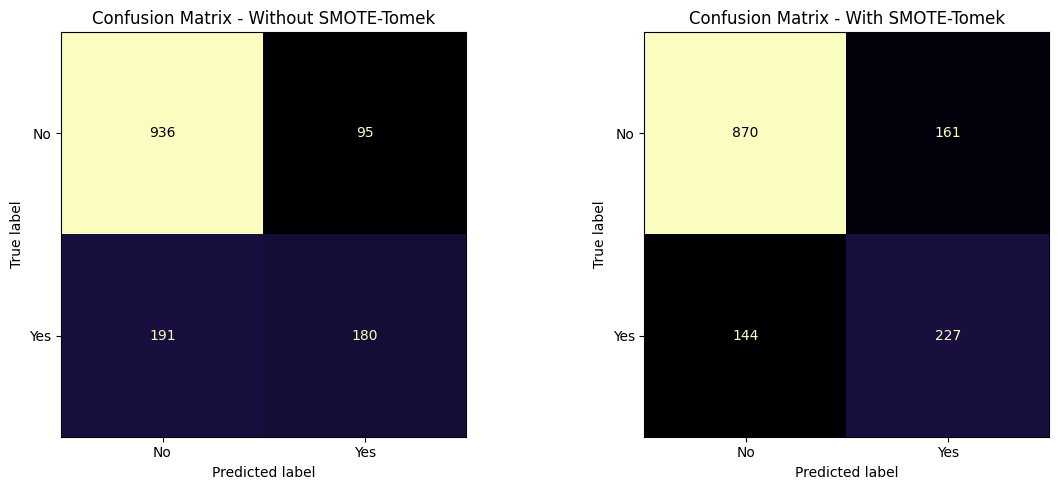

In [42]:
cm_normal = confusion_matrix(y_test, y_pred_normal)
cm_smote = confusion_matrix(y_test, y_pred_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_normal,
    display_labels=['No', 'Yes']
).plot(
    ax=axes[0],
    cmap='magma',
    colorbar=False
)

axes[0].set_title('Confusion Matrix - Without SMOTE-Tomek')

ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=['No', 'Yes']
).plot(
    ax=axes[1],
    cmap='magma',
    colorbar=False
)

axes[1].set_title('Confusion Matrix - With SMOTE-Tomek')

plt.tight_layout()
plt.show()

## XGBoost

In [43]:
from xgboost import XGBClassifier

xgboost = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [44]:
y_train_xgb = y_train.map({'No': 0, 'Yes': 1})
y_train_smote_xgb = y_train_smote.map({'No': 0, 'Yes': 1})
y_test_xgb = y_test.map({'No': 0, 'Yes': 1})

In [45]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_normal = GridSearchCV(
    estimator=xgboost,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

grid_smote = GridSearchCV(
    estimator=xgboost,
    param_grid=param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

In [46]:
grid_normal.fit(X_train, y_train_xgb)

grid_smote.fit(X_train_smote, y_train_smote_xgb)

,estimator,"XGBClassifier...state=42, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,objective,'binary:logistic'


In [47]:
print("Normal")
print("Best Parameter:", grid_normal.best_params_)
print(f"Best CV Score: {grid_normal.best_score_:.4f}")

print()

print("SMOTE-Tomek")
print("Best Parameter:", grid_smote.best_params_)
print(f"Best CV Score: {grid_smote.best_score_:.4f}")

Normal
Best Parameter: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.7284

SMOTE-Tomek
Best Parameter: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best CV Score: 0.8672


In [48]:
best_normal = grid_normal.best_estimator_
y_pred_normal = best_normal.predict(X_test)

best_smote = grid_smote.best_estimator_
y_pred_smote = best_smote.predict(X_test)

### Evaluation

In [49]:
print("Normal")
print(f"Accuracy: {accuracy_score(y_test_xgb, y_pred_normal):.4f}")
print(f"F1 Score: {f1_score(y_test_xgb, y_pred_normal, average='macro'):.4f}\n")
print(
    classification_report(
        y_test_xgb,
        y_pred_normal,
        target_names=['No', 'Yes']
    )
)

print()

print("SMOTE-Tomek")
print(f"Accuracy: {accuracy_score(y_test_xgb, y_pred_smote):.4f}")
print(f"F1 Score: {f1_score(y_test_xgb, y_pred_smote, average='macro'):.4f}\n")
print(
    classification_report(
        y_test_xgb,
        y_pred_smote,
        target_names=['No', 'Yes']
    )
)

Normal
Accuracy: 0.8046
F1 Score: 0.7313

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1031
         Yes       0.66      0.53      0.59       371

    accuracy                           0.80      1402
   macro avg       0.75      0.72      0.73      1402
weighted avg       0.80      0.80      0.80      1402


SMOTE-Tomek
Accuracy: 0.7632
F1 Score: 0.6989

              precision    recall  f1-score   support

          No       0.84      0.83      0.84      1031
         Yes       0.55      0.57      0.56       371

    accuracy                           0.76      1402
   macro avg       0.70      0.70      0.70      1402
weighted avg       0.77      0.76      0.76      1402



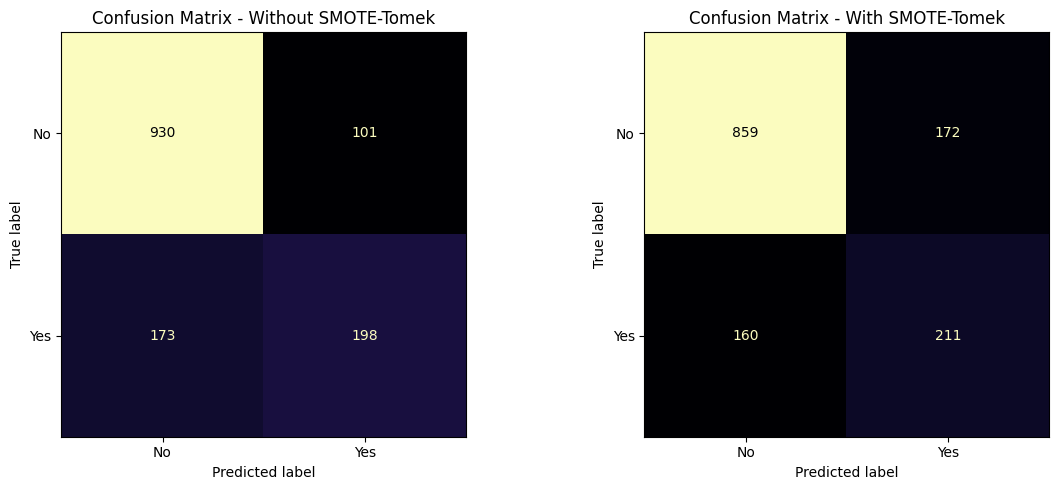

In [50]:
y_test_xgb = y_test.map({'No': 0, 'Yes': 1})

cm_normal = confusion_matrix(
    y_test_xgb,
    y_pred_normal,
    labels=[0, 1]
)

cm_smote = confusion_matrix(
    y_test_xgb,
    y_pred_smote,
    labels=[0, 1]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_normal,
    display_labels=['No', 'Yes']
).plot(ax=axes[0], cmap='magma', colorbar=False)

axes[0].set_title('Confusion Matrix - Without SMOTE-Tomek')

ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=['No', 'Yes']
).plot(ax=axes[1], cmap='magma', colorbar=False)

axes[1].set_title('Confusion Matrix - With SMOTE-Tomek')

plt.tight_layout()
plt.show()

Model Performance Conclusion

- The highest accuracy was achieved by XGBoost without SMOTE-Tomek, with an accuracy of 80.46%, while the highest macro F1-score was also achieved by the same configuration at 73.00%.

- XGBoost provided the best performance because its gradient boosting framework can effectively capture complex and non-linear relationships among features by sequentially combining multiple decision trees. This allows the model to learn more complex patterns in customer churn data compared with simpler models such as Logistic Regression.

- Logistic Regression achieved slightly lower performance because it assumes a relatively linear relationship between the features and the target, which may limit its ability to capture the more complex patterns present in customer churn data.

- Random Forest achieved competitive performance but was slightly lower than XGBoost. Although it can capture non-linear relationships, Random Forest builds trees independently and combines their predictions, while XGBoost sequentially focuses on correcting errors from previous trees, which can provide more effective learning of difficult patterns.

- The model also achieved the best macro F1-score, indicating that its performance was relatively well balanced across both No and Yes classes despite the original class imbalance.

- The application of SMOTE-Tomek did not improve the overall performance of the evaluated models. This suggests that altering the training class distribution did not provide additional predictive benefits for this dataset when evaluated on the original test distribution.

- The Logistic Regression feature importance identified Contract as the most influential feature in both scenarios. In real-world settings, contract type can reflect the level of customer commitment to the service. Customers on month-to-month contracts typically have greater flexibility to discontinue their subscription, while longer-term contracts imply a stronger commitment and may reduce short-term switching. This may explain why Contract contributes strongly to the model's churn predictions.

- Overall, XGBoost without SMOTE-Tomek was selected as the best-performing configuration based on its highest accuracy and macro F1-score.